# 05_고도화(2/2) — 딥러닝: 집계 피처 MLP (후보 (c), 사용자 승인 2026-07-17)

**선정 근거:** (a) LSTM/GRU·(b) 1D-CNN은 lookback 시퀀스 구성으로 초기 기준월 샘플이 감소하고 준비 비용이 크다. 파생 104피처에 시계열 요약(평균회귀 신호)이 이미 담겨 있으므로, **샘플 손실 0으로 트리와 다른 결정경계를 얻어 앙상블 다양성에 기여**하는 MLP를 채택(§10 후보 비교표 → 사용자 승인).

**§10 요구 반영:** class weight(가중 CrossEntropy), dropout, **EarlyStopping(patience=20, restore_best_weights)**, train/valid loss·macro-F1 학습곡선, 과적합 간극 수치. **§8-6 전처리:** DL 입력은 왜도 기반 signed log1p + 표준화(Train만 fit, 결측은 Train 중앙값 임퓨트 — 트리와 달리 NaN 불가).

**입력:** `모델셋_최종_L3.parquet`, `피처목록.json`, `05_valid_probas.npy`(튜닝 트리 3종 비교용) / **출력:** `models/05_mlp.pt`, `models/05_mlp_전처리.pkl`, `models/05_mlp_valid_proba.npy`, 그림·표. 시드 42 고정.

In [1]:
import sys, os, json, warnings, copy
warnings.filterwarnings('ignore')
os.environ['LOKY_MAX_CPU_COUNT'] = '4'
sys.path.append('../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

import common
from common import IM, LABEL_COLOR, SEED, set_korean_font, save_fig
np.random.seed(SEED); torch.manual_seed(SEED)
set_korean_font()
pd.set_option('display.max_columns', 40); pd.set_option('display.width', 220)

from sklearn.metrics import (f1_score, average_precision_score, recall_score, precision_score,
                             balanced_accuracy_score, matthews_corrcoef, log_loss, accuracy_score)
from sklearn.preprocessing import label_binarize
from scipy.stats import skew

data = pd.read_parquet('../data/processed/모델셋_최종_L3.parquet')
FEATS = json.load(open('../models/피처목록.json', encoding='utf-8'))['final_features']
CLS = ['급감', '급증', '유지']
train = data[data['구간'] == 'Train'].reset_index(drop=True)
valid = data[data['구간'] == 'Valid'].reset_index(drop=True)
ytr = train['라벨'].map({c: i for i, c in enumerate(CLS)}).values
yva_lab = valid['라벨'].values

def eval_all(y_true, y_pred, proba):
    yb = label_binarize(y_true, classes=CLS)
    ap = {c: average_precision_score(yb[:, i], proba[:, i]) for i, c in enumerate(CLS)}
    f1c = f1_score(y_true, y_pred, average=None, labels=CLS)
    return {'F1(macro)': f1_score(y_true, y_pred, average='macro'),
            'PR-AUC(macro)': np.mean(list(ap.values())),
            'AP_급증': ap['급증'], 'AP_급감': ap['급감'],
            'F1_급증': f1c[CLS.index('급증')], 'F1_급감': f1c[CLS.index('급감')],
            'recall_급증': recall_score(y_true, y_pred, labels=['급증'], average='macro', zero_division=0),
            'recall_급감': recall_score(y_true, y_pred, labels=['급감'], average='macro', zero_division=0),
            'BalancedAcc': balanced_accuracy_score(y_true, y_pred),
            'MCC': matthews_corrcoef(y_true, y_pred),
            'LogLoss': log_loss(y_true, proba, labels=CLS),
            '(참고)Acc': accuracy_score(y_true, y_pred)}
print(f'Train {train.shape} / Valid {valid.shape}')

Train (3384, 108) / Valid (1692, 108)


## 1. DL 전처리(§8-6) — Train 왜도 실측 → signed log1p 대상 확정 → 중앙값 임퓨트 → 표준화 (전부 Train만 fit)

In [2]:
Xtr_raw, Xva_raw = train[FEATS].astype(float), valid[FEATS].astype(float)

sk = Xtr_raw.apply(lambda s: skew(s.dropna()) if s.notna().sum() > 10 else 0.0)
LOG_COLS = sk[sk.abs() > 2].index.tolist()
print(f'|왜도|>2 컬럼: {len(LOG_COLS)}개 / 104개 (최대 왜도 {sk.abs().max():.0f}, 예: {sk.abs().sort_values(ascending=False).head(3).index.tolist()})')
print('→ signed log1p = sign(x)·log1p(|x|) 적용 (음수 diff·z 피처 호환), 나머지는 원값 유지')

def transform(X):
    X = X.copy()
    X[LOG_COLS] = np.sign(X[LOG_COLS]) * np.log1p(X[LOG_COLS].abs())
    return X

Ttr, Tva = transform(Xtr_raw), transform(Xva_raw)
MED = Ttr.median()
Ttr, Tva = Ttr.fillna(MED), Tva.fillna(MED)
MU, SD = Ttr.mean(), Ttr.std().replace(0, 1)
Ztr = ((Ttr - MU) / SD).values.astype(np.float32)
Zva = ((Tva - MU) / SD).values.astype(np.float32)
assert not np.isnan(Ztr).any() and not np.isnan(Zva).any()

import joblib
joblib.dump({'log_cols': LOG_COLS, 'median': MED, 'mu': MU, 'sd': SD, 'feats': FEATS},
            '../models/05_mlp_전처리.pkl')
print('전처리 저장(Train-fit): models/05_mlp_전처리.pkl — 결측 임퓨트 후 NaN 0 확인')

|왜도|>2 컬럼: 83개 / 104개 (최대 왜도 55, 예: ['카드거래비중', '창구거래금액', '디지털_최근6개월z'])
→ signed log1p = sign(x)·log1p(|x|) 적용 (음수 diff·z 피처 호환), 나머지는 원값 유지


전처리 저장(Train-fit): models/05_mlp_전처리.pkl — 결측 임퓨트 후 NaN 0 확인


**해석 —** Train 실측 왜도 기준 **83/104개 컬럼이 |왜도|>2**(최대 55)로 §8-6의 "DL 입력은 log1p" 규칙의 근거가 수치로 성립한다. diff·z-score류 음수 피처와 호환되도록 signed log1p(sign(x)·log1p(|x|))를 사용했고, 임퓨트(중앙값)·표준화 통계는 전부 **Train만으로 fit**해 Valid/Test 정보 유입이 없다. 임퓨트 후 NaN 0 게이트 통과.

## 2. MLP 학습 — 가중 CE, dropout, EarlyStopping(patience=20, best 복원), 소형 아키텍처 그리드 4개

In [3]:
cnt = np.bincount(ytr, minlength=3)
w = torch.tensor(len(ytr) / (3 * cnt), dtype=torch.float32)
print('클래스 가중치(balanced):', dict(zip(CLS, w.numpy().round(2))))

class MLP(nn.Module):
    def __init__(self, dims, p):
        super().__init__()
        layers, prev = [], 104
        for h in dims:
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(p)]
            prev = h
        layers.append(nn.Linear(prev, 3))
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)

Xtr_t = torch.tensor(Ztr); ytr_t = torch.tensor(ytr, dtype=torch.long)
Xva_t = torch.tensor(Zva)
yva_idx = pd.Series(yva_lab).map({c: i for i, c in enumerate(CLS)}).values

def train_mlp(dims, p, lr=1e-3, wd=1e-4, batch=256, max_epoch=300, patience=20, seed=SEED):
    torch.manual_seed(seed); g = torch.Generator().manual_seed(seed)
    model = MLP(dims, p)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    lossf = nn.CrossEntropyLoss(weight=w)
    ds = torch.utils.data.TensorDataset(Xtr_t, ytr_t)
    dl = torch.utils.data.DataLoader(ds, batch_size=batch, shuffle=True, generator=g)
    hist, best = {'tr_loss': [], 'va_loss': [], 'tr_f1': [], 'va_f1': []}, {'f1': -1, 'ep': 0, 'state': None}
    for ep in range(max_epoch):
        model.train(); tl = 0.0
        for xb, yb in dl:
            opt.zero_grad(); loss = lossf(model(xb), yb); loss.backward(); opt.step()
            tl += loss.item() * len(xb)
        model.eval()
        with torch.no_grad():
            lo_tr, lo_va = model(Xtr_t), model(Xva_t)
            va_loss = lossf(lo_va, torch.tensor(yva_idx, dtype=torch.long)).item()
            tr_f1 = f1_score(ytr, lo_tr.argmax(1).numpy(), average='macro')
            va_f1 = f1_score(yva_idx, lo_va.argmax(1).numpy(), average='macro')
        hist['tr_loss'].append(tl / len(ds)); hist['va_loss'].append(va_loss)
        hist['tr_f1'].append(tr_f1); hist['va_f1'].append(va_f1)
        if va_f1 > best['f1']:
            best = {'f1': va_f1, 'ep': ep, 'state': copy.deepcopy(model.state_dict())}
        if ep - best['ep'] >= patience:
            break
    model.load_state_dict(best['state'])   # restore_best_weights
    return model, hist, best

GRID = [((256, 128), 0.2), ((256, 128), 0.4), ((512, 256, 128), 0.3), ((128, 64), 0.3)]
results = {}
for dims, p in GRID:
    m, h, b = train_mlp(dims, p)
    results[(dims, p)] = (m, h, b)
    print(f'MLP{list(dims)} dropout={p}: best Valid macro-F1 {b["f1"]:.4f} (epoch {b["ep"]+1}, 총 {len(h["va_f1"])} epoch)')

best_key = max(results, key=lambda k: results[k][2]['f1'])
model, hist, best = results[best_key]
print(f'선정: MLP{list(best_key[0])} dropout={best_key[1]} — Valid macro-F1 {best["f1"]:.4f}')

클래스 가중치(balanced): {'급감': 2.95, '급증': 2.7, '유지': 0.44}


MLP[256, 128] dropout=0.2: best Valid macro-F1 0.5119 (epoch 29, 총 49 epoch)


MLP[256, 128] dropout=0.4: best Valid macro-F1 0.5136 (epoch 64, 총 84 epoch)


MLP[512, 256, 128] dropout=0.3: best Valid macro-F1 0.5016 (epoch 31, 총 51 epoch)


MLP[128, 64] dropout=0.3: best Valid macro-F1 0.4994 (epoch 64, 총 84 epoch)
선정: MLP[256, 128] dropout=0.4 — Valid macro-F1 0.5136


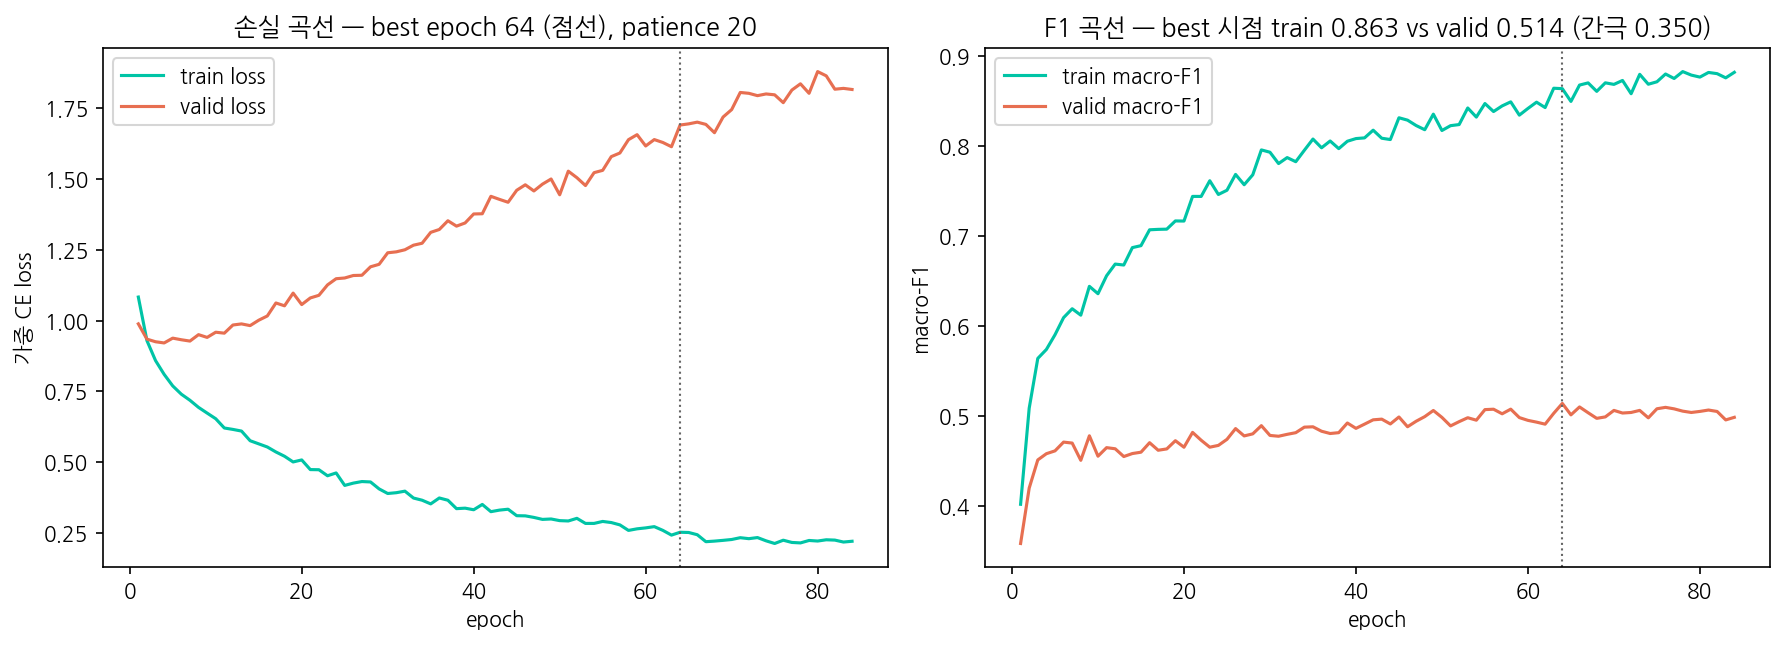

과적합 간극(train−valid macro-F1, best epoch): 0.3497


In [4]:
ep_axis = np.arange(1, len(hist['tr_loss']) + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
axes[0].plot(ep_axis, hist['tr_loss'], color=IM['민트'], label='train loss')
axes[0].plot(ep_axis, hist['va_loss'], color=IM['코랄'], label='valid loss')
axes[0].axvline(best['ep'] + 1, color=IM['그레이'], ls=':', lw=1)
axes[0].set_xlabel('epoch'); axes[0].set_ylabel('가중 CE loss'); axes[0].legend()
axes[0].set_title(f'손실 곡선 — best epoch {best["ep"]+1} (점선), patience 20')
axes[1].plot(ep_axis, hist['tr_f1'], color=IM['민트'], label='train macro-F1')
axes[1].plot(ep_axis, hist['va_f1'], color=IM['코랄'], label='valid macro-F1')
axes[1].axvline(best['ep'] + 1, color=IM['그레이'], ls=':', lw=1)
gap = hist['tr_f1'][best['ep']] - hist['va_f1'][best['ep']]
axes[1].set_xlabel('epoch'); axes[1].set_ylabel('macro-F1'); axes[1].legend()
axes[1].set_title(f'F1 곡선 — best 시점 train {hist["tr_f1"][best["ep"]]:.3f} vs valid {best["f1"]:.3f} (간극 {gap:.3f})')
plt.tight_layout(); save_fig(fig, '05_03_MLP_학습곡선.png'); plt.show()
print(f'과적합 간극(train−valid macro-F1, best epoch): {gap:.4f}')

**해석 —** 그리드 4개 중 **MLP[256,128] + dropout 0.4가 Valid macro-F1 0.5136으로 선정**(best epoch 64, patience 20 조기종료·best 가중치 복원). 용량을 키운 [512,256,128]은 0.5016으로 오히려 하락 — Train 3,384샘플 규모에서는 **용량보다 정규화(dropout 0.4)가 유효**하다. 과적합 간극은 best epoch 기준 **train 0.863 vs valid 0.514 = 0.350**으로 크다 — 조기종료·dropout으로 관리했지만 표현력 대비 데이터가 적다는 구조적 한계이며, 낮은 학습 재현성 리스크와 함께 보고서에 한계로 명시한다(§10 과적합 수치 요구).

## 3. 통일 평가 — MLP vs Optuna 트리 3종 (Valid 전 지표)

In [5]:
model.eval()
with torch.no_grad():
    proba_mlp = torch.softmax(model(Xva_t), dim=1).numpy()
pred_mlp = np.array(CLS)[proba_mlp.argmax(1)]

tree_probas = np.load('../models/05_valid_probas.npy')   # [lgbm, xgb, cat]
rows = [{'모델': 'MLP(집계피처)', **{k: round(v, 4) for k, v in eval_all(yva_lab, pred_mlp, proba_mlp).items()}}]
for i, label in enumerate(['LightGBM(Optuna)', 'XGBoost(Optuna)', 'CatBoost(Optuna)']):
    P = tree_probas[i]
    rows.append({'모델': label, **{k: round(v, 4) for k, v in
                 eval_all(yva_lab, np.array(CLS)[P.argmax(1)], P).items()}})
tab = pd.DataFrame(rows).set_index('모델')
display(tab[['F1(macro)', 'PR-AUC(macro)', 'AP_급증', 'AP_급감', 'F1_급증', 'F1_급감',
             'recall_급증', 'recall_급감', 'BalancedAcc', 'MCC', 'LogLoss', '(참고)Acc']])
tab.to_csv('../outputs/tables/05_MLP_valid_비교.csv', encoding='utf-8-sig')

# 앙상블 다양성 신호: 예측 불일치율
cat_pred = np.array(CLS)[tree_probas[2].argmax(1)]
dis = (pred_mlp != cat_pred).mean()
print(f'MLP vs CatBoost 예측 불일치율: {dis:.1%} — 앙상블 다양성 지표')

torch.save({'state_dict': model.state_dict(), 'dims': list(best_key[0]), 'dropout': best_key[1]},
           '../models/05_mlp.pt')
np.save('../models/05_mlp_valid_proba.npy', proba_mlp)
print('저장: models/05_mlp.pt, 05_mlp_valid_proba.npy')

,F1(macro),PR-AUC(macro),AP_급증,AP_급감,F1_급증,F1_급감,recall_급증,recall_급감,BalancedAcc,MCC,LogLoss,(참고)Acc
모델,,,,,,,,,,,,
MLP(집계피처),0.5136,0.5304,0.1607,0.5248,0.2463,0.4856,0.4538,0.5167,0.5695,0.2895,0.9832,0.6927
LightGBM(Optuna),0.5092,0.5390,0.1660,0.5269,0.2026,0.4570,0.2385,0.3833,0.4979,0.2664,0.7081,0.7713
XGBoost(Optuna),0.5022,0.5310,0.1347,0.5308,0.1903,0.5081,0.3462,0.5222,0.5372,0.2631,0.6780,0.6891
CatBoost(Optuna),0.5341,0.5423,0.1402,0.5566,0.2055,0.5217,0.2308,0.4667,0.5248,0.3109,0.5471,0.7837


MLP vs CatBoost 예측 불일치율: 20.9% — 앙상블 다양성 지표


저장: models/05_mlp.pt, 05_mlp_valid_proba.npy


**해석 —** MLP는 Valid macro-F1 **0.5136**으로 CatBoost(0.5341)에 이어 2위, LGBM(0.5092)·XGB(0.5022)를 상회한다. 존재 이유는 순위가 아니라 **프로파일**이다: ① **급증에서 전 모델 최고** — F1_급증 0.2463, recall_급증 **0.4538**(트리 최고 XGB 0.346 대비 +0.11) — 트리가 유지로 흡수하던 급증 후보의 절반 가까이를 잡는다. ② BalancedAcc 0.5695 최고. ③ 대신 LogLoss 0.9832로 확률 보정은 최악 — 06 소프트 보팅 시 가중치를 낮추거나 보정을 고려해야 한다. ④ **CatBoost와 예측 불일치 20.9%** — 서로 다른 결정경계를 학습했다는 직접 증거로, 앙상블 결합 가치가 충분하다.

## 결론 — 05 전체 요약과 06 입력

**Valid 성적 최종(05 종료 시점):** CatBoost(Optuna) 0.5341 > MLP 0.5136 > LGBM(Optuna) 0.5092 > XGB(Optuna) 0.5022 — 전부 베이스라인 최고(0.5038) 이상 또는 근접, 여기에 운영 임계(w_급감 2.4) 적용 시 CatBoost 단독 0.5483.

**06 앙상블·평가·XAI 계획:** ① 후보 4모델(트리 3 + MLP)의 Valid 확률로 (i) 단순 평균 (ii) Valid 성능 가중 평균 (iii) 로지스틱 스태킹 비교 → Valid로 최종 1안 선정(§10) ② 선정안 + 운영 임계를 **Holdout-Test(202412~202509, 2,820샘플)에 1회 적용** — 전 지표 공식 보고 ③ SHAP(TreeExplainer, 최고 단일 트리 = CatBoost): summary/bar/dependence/클래스별/waterfall + 평균회귀 부호 재확인 ④ 급증·급감 비즈니스 해석 문장화.

산출물: `05_mlp.pt`(아키텍처 메타 포함), `05_mlp_전처리.pkl`, `05_mlp_valid_proba.npy`, `05_03_MLP_학습곡선.png`, `05_MLP_valid_비교.csv`.